In [1]:
import torch
import math
import random
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
import torchvision.transforms as T
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image 
import PIL
import numpy as np
import torchvision
import os

In [2]:
torch.__version__

'2.0.0+cu117'

In [3]:
torchvision.__version__

'0.15.1+cu117'

In [4]:
torch.cuda.is_available()

True

# Details of the HyperParameters:
<ul>
    <li>Epochs controls the number of iterations for the training loop</li>
    <li>Display_step determines after how many steps the images will be displayed for comparison</li>
    <li>Batch_size controls images per batch for training</li>
    <li>Crit_repeats determines how many times critic is updated per backward pass of generator. This is an element of Wasserstein Loss</li>
    <li>Learning_rate determines how fast the model learns and approaches convergence. Optimal learning_rate for ACGAN is 0.0002</li>
    <li>Beta_1 and Beta_2 are the hyperparameters for Adam Optimizer. Optimal values according to ACGAN Paper are already set</li>
    <li>Lambda_ is a hyperparameter for controlling the gradient penalty in Wasserstein Loss</li>
    <li>z_dim is the noise vector's dimension and nDz and nGz are the hidden dimensions for the Critic and Generator respectively</li>
    <li>Image_channels is 1 in our case since we are dealing with gray-scale images</li>
    <li>Image_size controls the size of our image</li>
    <li>Conditional will always be True in our case since we are using ACGAN. I used it initially when building the network but leave it as True</li>
    <li>n_images is the number of images to be generated for checking the performance later on. It must be equal to the batch_size</li>
    <li>Size is the shape or the dimensions of an image</li>
    <li>NumClasses specify how many classes we are going to use. In our case, 2</li>
    <li>Device specifies whether we are training on CPU or GPU. For CPU use 'cpu' and for GPU use 'cuda'</li>
    <li>Loss specifies which loss are we using. I am using Negative Log Likelihood for Labels' comparison and BCELoss or Wasserstein Loss for Generator and Critic. Pass 'BCE' for BCELoss and 'W' for Wasserstein Loss</li>
    <li>Trained determines if we have already trained the model and now we are further training it. In this case, save the model_states using the code in third-last cell and give paths to the model as arguments</li>

In [5]:
epochs = 50
display_step = 25
batch_size = 32
crit_repeats = 5
learning_rate = 0.0002
beta_1 = 0.9
beta_2 = 0.999
lambda_ = 10
z_dim = 100
img_channels = 1
nGz = 32
nDz = 32
image_size = 128
conditional = True
n_images = batch_size
size = (1, 128, 128)
numClasses = 29
device = 'cpu'
loss = 'BCE'
trained = False

In [6]:
DATA_DIR = 'Hijja Edited Enhanced'
stats = (0.5), (0.5)

In [7]:
class SortedImageFolder(ImageFolder):
    def __init__(self, root, transform = None):
        # Sort classes numerically
        classes = sorted(
            [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))],
            key = lambda x: int(x)
        )
        # Create class-to-index mapping
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        # Initialize parent class (ImageFolder) with sorted classes
        super().__init__(root, transform = transform, target_transform = None)

    def find_classes(self, directory):
        # Return the sorted class names and their indices
        classes = list(self.class_to_idx.keys())
        class_to_idx = self.class_to_idx
        return classes, class_to_idx

In [8]:
train_ds = SortedImageFolder(DATA_DIR, transform = T.Compose([
    T.Grayscale(num_output_channels = 1),
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),
    T.Normalize(*stats)])
)

dataloader = DataLoader(
    train_ds, 
    batch_size, 
    shuffle = True, 
    num_workers = 0, 
    pin_memory = True
)

In [9]:
for real, labels in tqdm(dataloader):
    break

  0%|          | 0/401 [00:00<?, ?it/s]

In [10]:
real.shape

torch.Size([32, 1, 128, 128])

In [11]:
labels.shape

torch.Size([32])

In [12]:
train_ds.classes[0], train_ds.classes[28]

('0', '28')

In [13]:
def show_tensor_images(image_tensor, num_images = 25, size = (1, 28, 28)):
    image_tensor = (image_tensor + 1) / 2
    image_unflat = image_tensor.detach().cpu()
    image_grid = make_grid(image_unflat[:num_images], nrow = 5)
    images = image_unflat[:num_images]
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()
#     for i in range(images.shape[0]):
#         image = (images[i] * 0.5) + 0.5
#         image = image.squeeze().numpy()
#         image = (image * 255).astype(np.uint8)
#         image = Image.fromarray(image, mode = 'L')
#         image.save('GeneratedImages/image_' + str(i) + '.png')

In [14]:
def combineVectors(v1, v2):
    return torch.cat((v1, v2), axis = 1)

In [15]:
def oneHotEncode(numClasses, labels):
    return nn.functional.one_hot(labels, numClasses)

In [16]:
def getInputDimensions(z_dim, shape, numClasses):
    generator_input_dim = z_dim + numClasses
    discriminator_input_dim = shape[0] + numClasses
    return generator_input_dim, discriminator_input_dim

In [17]:
def generate_noise(n_examples, z_dim, device = 'cpu'):
    noise = torch.randn(n_examples, z_dim, device = device)
    return noise

In [18]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)

In [19]:
class Generator(nn.Module):
    def __init__(self, z_dim = 10, img_channels = 1, hidden_dims = 64):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.gen = nn.Sequential (
            self.make_gen_block(z_dim, hidden_dims * 4),
            self.make_gen_block(hidden_dims * 4, hidden_dims * 8),
            self.make_gen_block(hidden_dims * 8, hidden_dims * 16),
            self.make_gen_block(hidden_dims * 16, hidden_dims * 8),
            self.make_gen_block(hidden_dims * 8, hidden_dims * 4),
            self.make_gen_block(hidden_dims * 4, hidden_dims),
            self.make_gen_block(hidden_dims, img_channels, kernel_size = 4, final_layer = True)
        )
    def make_gen_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, padding = 1, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.BatchNorm2d(output_channels),
                nn.ReLU()
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.Tanh()
            )
    def unsqueeze_noise(self, noise):
        return noise.view(len(noise), self.z_dim, 1, 1)
    def forward(self, noise):
        noise_in = self.unsqueeze_noise(noise)
        return self.gen(noise_in)

In [20]:
class Critic(nn.Module):
    def __init__(self, img_channels = 1, hidden_dims = 64):
        super(Critic, self).__init__()
        self.crit = nn.Sequential (
            self.make_crit_block(img_channels, hidden_dims),
            self.make_crit_block(hidden_dims, hidden_dims * 2),
            self.make_crit_block(hidden_dims * 2, hidden_dims * 4),
            self.make_crit_block(hidden_dims * 4, hidden_dims * 8),
            self.make_crit_block(hidden_dims * 8, hidden_dims * 16),
        )
        self.fc = nn.Linear(hidden_dims * 16 * 4 * 4, 1)
        self.fc_aux = nn.Linear(hidden_dims * 16 * 4 * 4, 1)
        self.sigmoid_1 = nn.Sigmoid()
        self.sigmoid_2 = nn.Sigmoid()
    def make_crit_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, padding = 1, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace = True),
                nn.Dropout(0.5, inplace = False)
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride, padding)
            )
    def forward(self, img):
        img_ = self.crit(img)
        img_fc = self.fc(img_.reshape((img_.shape[0], img_.shape[1] * img_.shape[2] * img_.shape[3])))
        img_fc_aux = self.fc_aux(img_.reshape((img_.shape[0], img_.shape[1] * img_.shape[2] * img_.shape[3])))
        label_imgs = self.sigmoid_1(img_fc_aux).view(-1, 1).squeeze(1)
        real_fake = self.sigmoid_2(img_fc).view(-1, 1).squeeze(1)
        return real_fake, label_imgs

In [21]:
def get_gradient(crit, real, fake, epsilon):
    interpolated_img = real * epsilon + fake * (1 - epsilon)
    pred, _ = crit(interpolated_img)
    grad = torch.autograd.grad(
        inputs = interpolated_img,
        outputs = pred,
        grad_outputs = torch.ones_like(pred), 
        create_graph = True,
        retain_graph = True        
    )[0]
    return grad

In [22]:
def gradient_penalty(gradient):
    gradient = gradient.view(len(gradient), -1)
    gradient_norm = gradient.norm(2, dim=1)   
    penalty = torch.mean((gradient_norm - 1) ** 2)
    return penalty

In [23]:
def wasserstein_loss_gen(fake_pred):
    return -torch.mean(fake_pred)

In [24]:
def wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_ = 0.1):
    crit_loss = torch.mean(fake_pred) - torch.mean(real_pred) + torch.mean(lambda_ * (penalty))
    return crit_loss

In [25]:
def generate_images(trained, path_gen, generator, nGz, n_examples, z_dim, conditional, numClasses = 0, num_images = 25, size = (1, 28, 28), labels = [], device = 'cpu'):
    if trained:
        img_channels = 1
        generator_input_dim, _ = getInputDimensions(z_dim, size, numClasses)
        generator = Generator(generator_input_dim, img_channels, nGz).to(device)
        generator.load_state_dict(torch.load(path_gen))
    if conditional == True:
        if len(labels) == 0:
            for i in range(num_images):
                labels.append(random.randint(0, numClasses - 1))
            labels = torch.Tensor(labels).to(device)
        elif len(labels) == 1:
            labels = torch.floor(labels[0] + torch.rand(num_images, ))
            labels = labels.to(device)
        labels = labels.to(torch.int64)
        one_hot = oneHotEncode(numClasses, labels)
        pred_noise = generate_noise(n_examples, z_dim, device)
        pred_noise_labels = combineVectors(pred_noise, one_hot)
        pred_images = generator(pred_noise_labels)
    else:
        pred_noise = generate_noise(n_examples, z_dim, device)
        pred_images = generator(pred_noise)
    show_tensor_images(pred_images, num_images, size)

In [26]:
def GAN(trained, epochs, path_gen, path_disc, path_gen_opt, path_disc_opt, nDz, nGz, display_step, img_channels, crit_repeats, learning_rate, beta_1, beta_2, lambda_, z_dim, shape, numClasses, dataloader, loss, device):
    generator_input_dim, _ = getInputDimensions(z_dim, shape, numClasses)
    gen = Generator(generator_input_dim, img_channels, nGz).to(device)
    crit = Critic(img_channels, nDz).to(device)

    gen_optimizer = torch.optim.Adam(gen.parameters(), lr = learning_rate, betas = (beta_1, beta_2))
    crit_optimizer = torch.optim.Adam(crit.parameters(), lr = learning_rate, betas = (beta_1, beta_2))
    
    if not trained:
        gen = gen.apply(weights_init)
        crit = crit.apply(weights_init)
    else:
        gen.load_state_dict(torch.load(path_gen))
        crit.load_state_dict(torch.load(path_disc))
        gen_optimizer.load_state_dict(torch.load(path_gen_opt))
        crit_optimizer.load_state_dict(torch.load(path_disc_opt))
    
    if loss == 'BCE':
        criterion = nn.BCELoss()
    criterion_aux = nn.NLLLoss()
    
    cur_step = 0
    generator_losses = []
    critic_losses = []
    for epoch in range(epochs):
        for real, labels in tqdm(dataloader):
            cur_batch_size = len(real)
            real = real.to(device)
            one_hot = oneHotEncode(numClasses, labels.to(device)) 
            image_one_hot_labels = one_hot[:, :, None, None]
            image_one_hot_labels = image_one_hot_labels.repeat(1, 1, shape[1], shape[2])
            mean_iteration_critic_loss = 0
            if loss == 'W':
                for _ in range(crit_repeats):
                    crit_optimizer.zero_grad()
                    fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                    epsilon = torch.rand(len(real), 1, 1, 1, device = device, requires_grad = True)
                    fake_noise_labels = combineVectors(fake_noise, one_hot)
                    fake_imgs = gen(fake_noise_labels)
                    fake_pred, label_imgs_fake = crit(fake_imgs)
                    real_pred, label_imgs_real = crit(real)
                    grad = get_gradient(crit, real, fake_imgs, epsilon)
                    penalty = gradient_penalty(grad)
                    crit_loss_wasserstein = wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_)
                    crit_loss_labels_fake = criterion_aux(label_imgs_fake, labels.to(device))
                    crit_loss_labels_real = criterion_aux(label_imgs_real, labels.to(device))
                    crit_loss = crit_loss_wasserstein + crit_loss_labels_fake + crit_loss_labels_real
                    mean_iteration_critic_loss += crit_loss.item() / crit_repeats
                    critic_losses += [mean_iteration_critic_loss]
                    crit_loss.backward(retain_graph = True)
                    crit_optimizer.step()
                cur_step += 1
                
                gen_optimizer.zero_grad()
                fake_noise_1 = generate_noise(cur_batch_size, z_dim, device = device)
                fake_noise_labels_1 = combineVectors(fake_noise_1, one_hot)
                fake_imgs_1 = gen(fake_noise_labels_1)
                fake_pred_1, labels_imgs_fake_1 = crit(fake_imgs_1)
                gen_loss = wasserstein_loss_gen(fake_pred_1)
                gen_loss_labels = criterion_aux(labels_imgs_fake_1, labels.to(device))
                gen_loss = gen_loss + gen_loss_labels
                gen_loss.backward(retain_graph = True)
                gen_optimizer.step()
                generator_losses += [gen_loss.item()]
                
            elif loss == 'BCE':
                crit_optimizer.zero_grad()
                fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                fake_noise_labels = combineVectors(fake_noise, one_hot)
                fake_imgs = gen(fake_noise_labels)
                fake_pred, label_imgs_fake = crit(fake_imgs)
                real_pred, label_imgs_real = crit(real)
                crit_loss_fake = criterion(fake_pred, torch.zeros_like(fake_pred))
                crit_loss_real = criterion(real_pred, torch.ones_like(real_pred))
                crit_loss_fake_labels = criterion_aux(label_imgs_fake, labels.to(device))
                crit_loss_real_labels = criterion_aux(label_imgs_real, labels.to(device))
                crit_loss_for_fake = crit_loss_fake + crit_loss_fake_labels
                crit_loss_for_fake.backward(retain_graph = True)
                crit_loss_for_real = crit_loss_real + crit_loss_real_labels
                crit_loss_for_real.backward(retain_graph = True)
                crit_loss = crit_loss_for_fake + crit_loss_for_real
                critic_losses += [crit_loss.item()]
                crit_optimizer.step()
                cur_step += 1
                
                gen_optimizer.zero_grad()
                fake_pred_1, label_imgs_fake_1 = crit(fake_imgs)
                gen_loss_fake = criterion(fake_pred_1, torch.ones_like(fake_pred_1))
                gen_loss_labels = criterion_aux(label_imgs_fake_1, labels.to(device))
                gen_loss = gen_loss_fake + gen_loss_labels
                gen_loss.backward(retain_graph = True)
                gen_optimizer.step()
                generator_losses += [gen_loss.item()]
            
            if cur_step % display_step == 0 and cur_step > 0:
                gen_mean = sum(generator_losses[-display_step:]) / display_step
                crit_mean = sum(critic_losses[-display_step:]) / display_step
                print(f"Epoch {epoch}, step {cur_step}: Generator loss: {gen_mean}, critic loss: {crit_mean}")
                show_tensor_images(fake_imgs, size = shape)
                show_tensor_images(real, size = shape)
                step_bins = 20
                num_examples = (len(generator_losses) // step_bins) * step_bins
                plt.plot(
                    range(num_examples // step_bins), 
                    torch.Tensor(generator_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Generator Loss"
                )
                plt.plot(
                    range(num_examples // step_bins), 
                    torch.Tensor(critic_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Critic Loss"
                )
                plt.legend()
                plt.show()
    return gen, crit, gen_optimizer, crit_optimizer

<p>In case you are passing trained as True then you have to pass the paths to the saved stats of the model, i.e. path_gen, path_disc, path_gen_opt and path_disc_opt. In case you are training from scratch, pass trained as False and pass empty string '' in place of path_gen, path_disc, path_gen_opt and path_disc_opt.</p>

  0%|          | 0/401 [00:00<?, ?it/s]

Epoch 0, step 25: Generator loss: 0.21935956954956054, critic loss: 0.26566008806228636


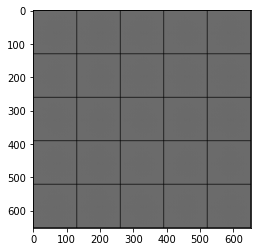

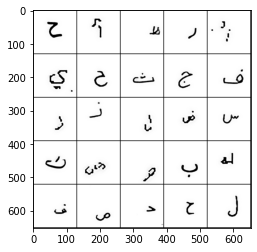

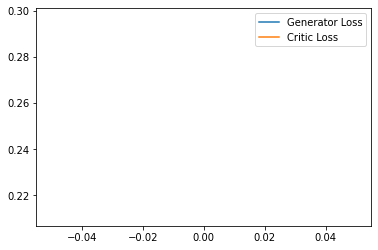

Epoch 0, step 50: Generator loss: 0.5076081728935242, critic loss: -0.255171480178833


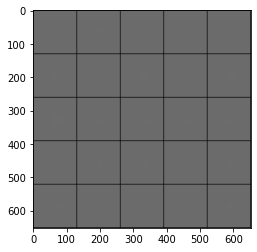

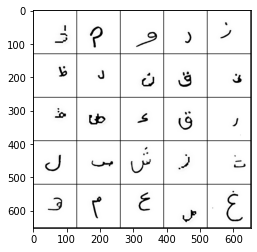

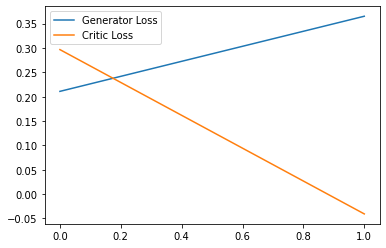

Epoch 0, step 75: Generator loss: 1.150180127620697, critic loss: -1.0506323456764222


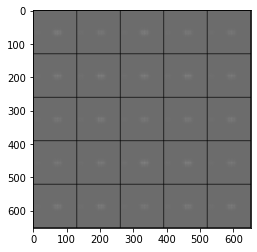

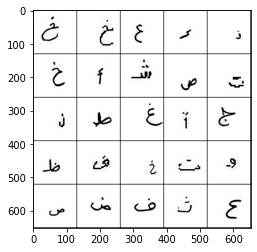

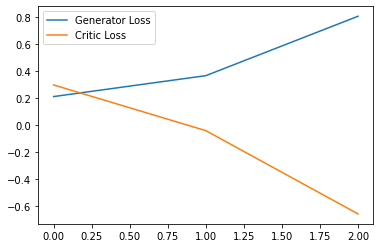

Epoch 0, step 100: Generator loss: 2.027955913543701, critic loss: -1.6245210552215577


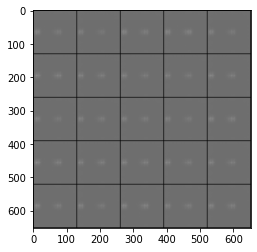

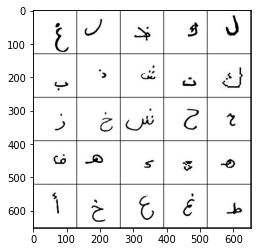

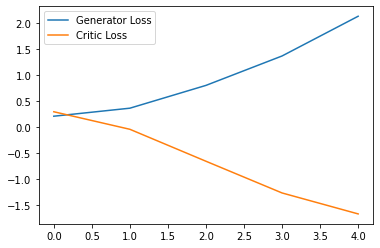

Epoch 0, step 125: Generator loss: 2.703381071090698, critic loss: -1.821836633682251


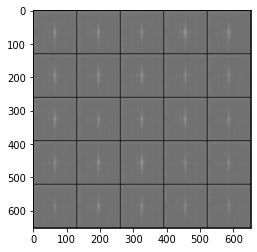

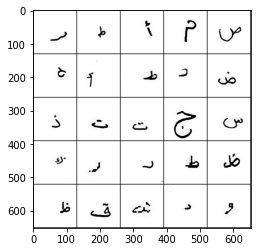

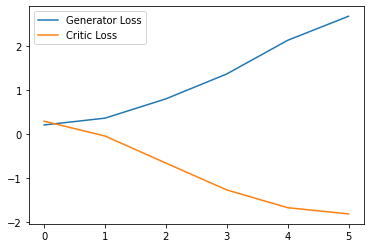

Epoch 0, step 150: Generator loss: 3.0148743534088136, critic loss: -1.8904043769836425


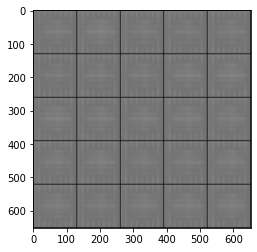

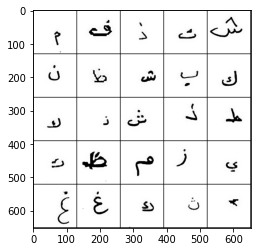

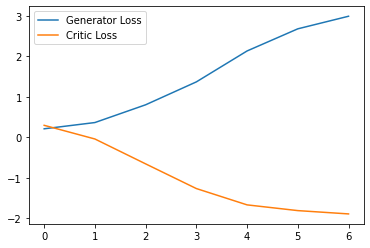

Epoch 0, step 175: Generator loss: 3.2912441730499267, critic loss: -1.9325075674057006


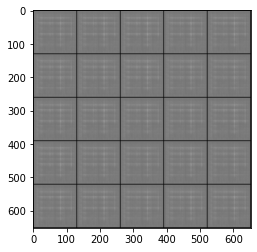

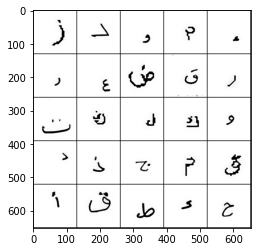

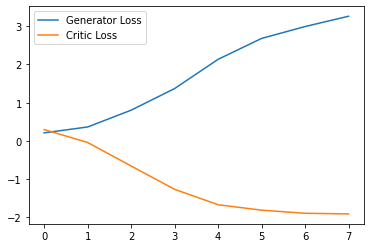

Epoch 0, step 200: Generator loss: 3.307184352874756, critic loss: -1.9230092287063598


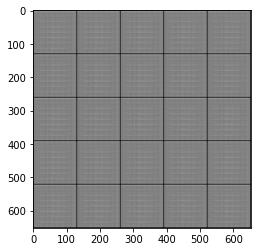

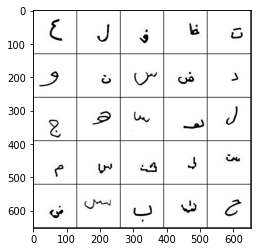

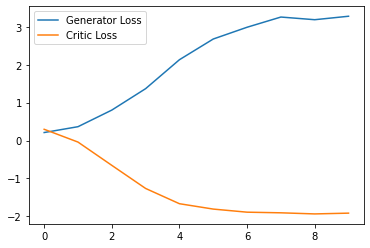

Epoch 0, step 225: Generator loss: 4.08988826751709, critic loss: -1.9463236474990844


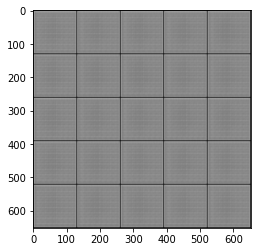

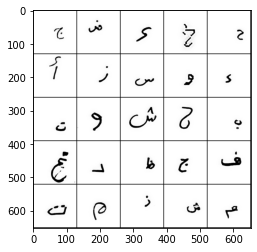

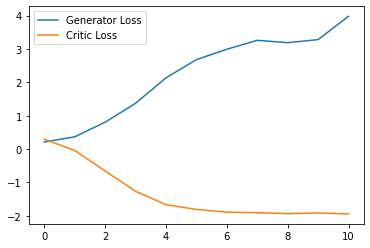

Epoch 0, step 250: Generator loss: 3.842642297744751, critic loss: -1.96261616230011


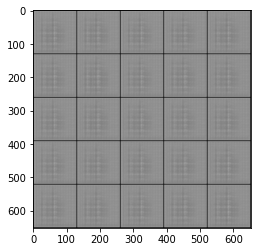

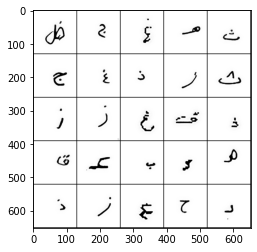

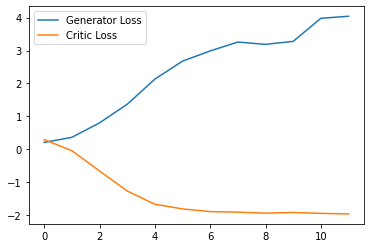

Epoch 0, step 275: Generator loss: 3.971534595489502, critic loss: -1.956126480102539


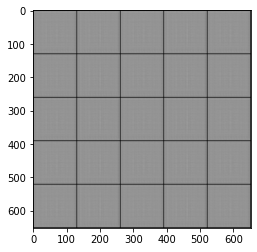

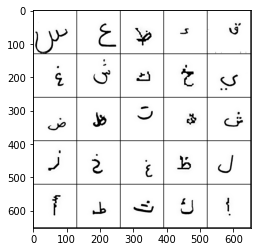

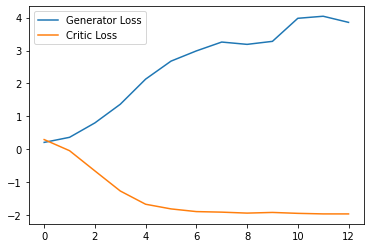

Epoch 0, step 300: Generator loss: 3.952150402069092, critic loss: -1.930088725090027


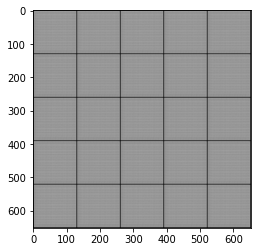

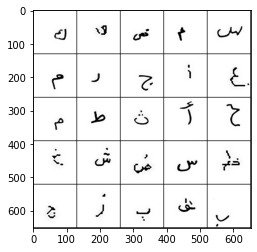

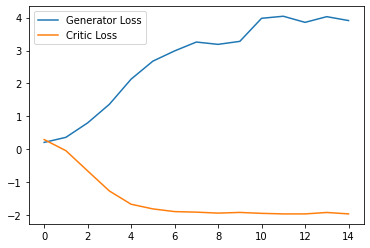

Epoch 0, step 325: Generator loss: 4.417617683410644, critic loss: -1.9376956939697265


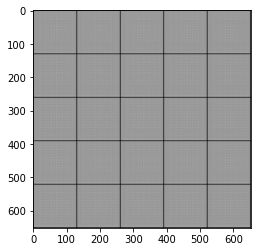

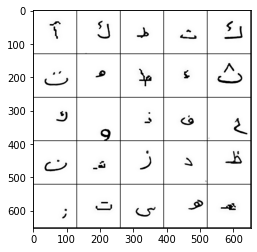

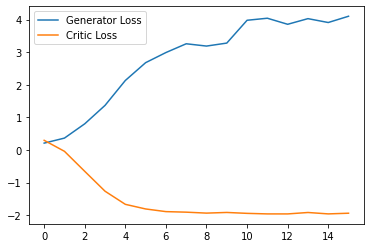

Epoch 0, step 350: Generator loss: 5.211043939590454, critic loss: -1.9393811273574828


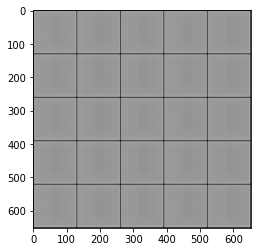

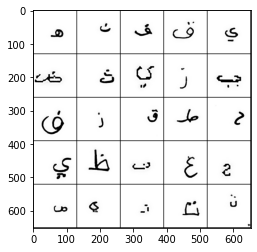

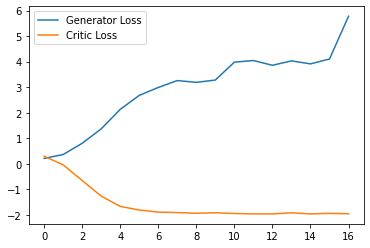

Epoch 0, step 375: Generator loss: 5.570645294189453, critic loss: -1.9775945663452148


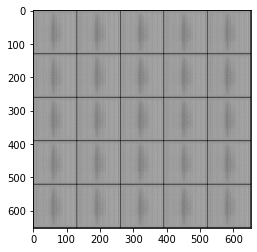

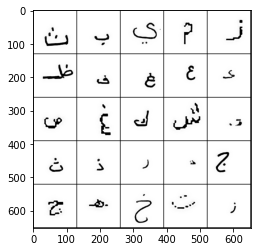

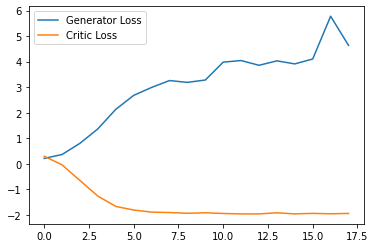

Epoch 0, step 400: Generator loss: 6.651867389678955, critic loss: -1.9893388986587524


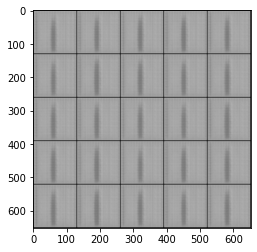

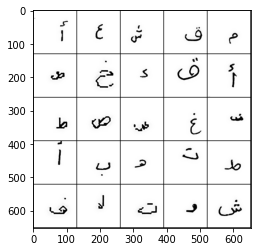

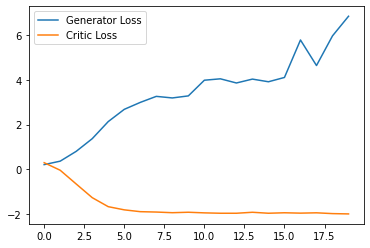

  0%|          | 0/401 [00:00<?, ?it/s]

Epoch 1, step 425: Generator loss: 5.334702701568603, critic loss: -1.9905950260162353


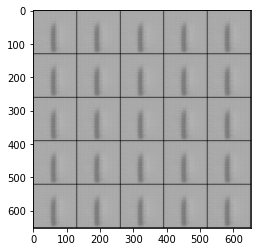

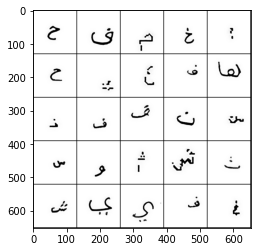

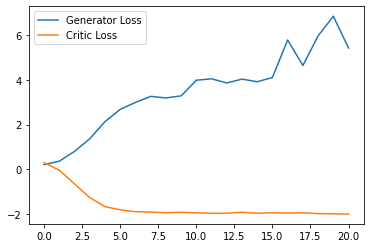

Epoch 1, step 450: Generator loss: 5.116041126251221, critic loss: -1.9827254867553712


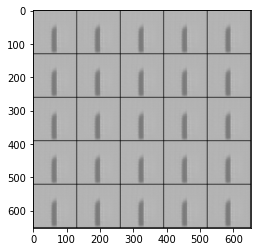

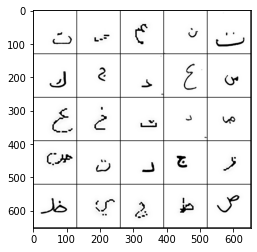

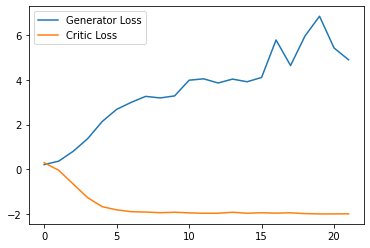

Epoch 1, step 475: Generator loss: 4.802649481296539, critic loss: -1.575219190120697


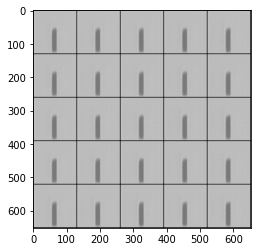

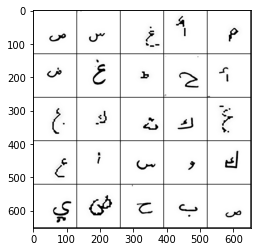

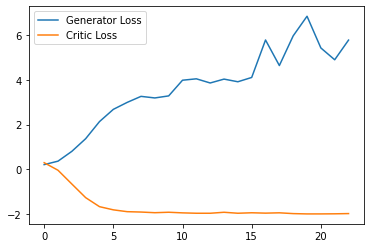

Epoch 1, step 500: Generator loss: 2.760107204914093, critic loss: -1.9084221935272216


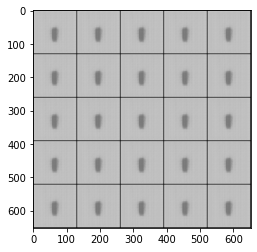

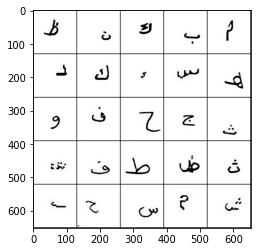

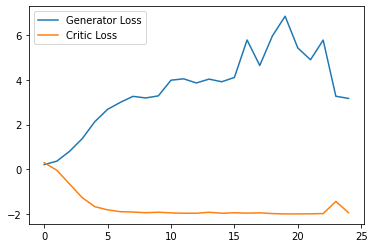

Epoch 1, step 525: Generator loss: 3.557540273666382, critic loss: -1.9157482862472535


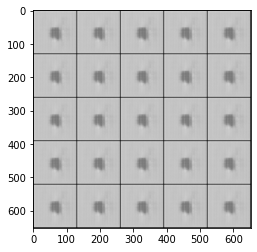

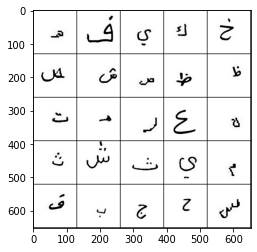

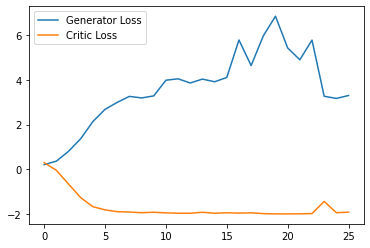

Epoch 1, step 550: Generator loss: 4.544097013473511, critic loss: -1.9516769552230835


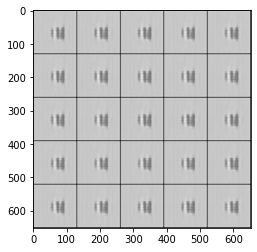

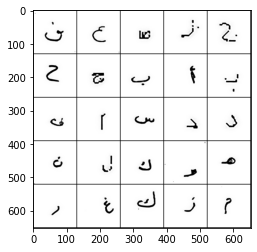

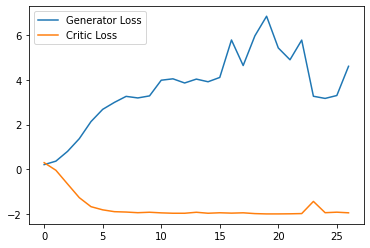

Epoch 1, step 575: Generator loss: 5.503661785125733, critic loss: -1.9764032411575316


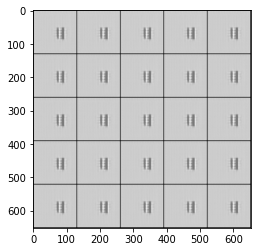

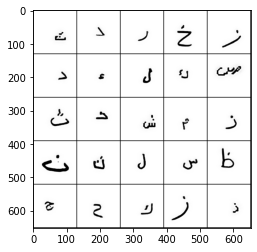

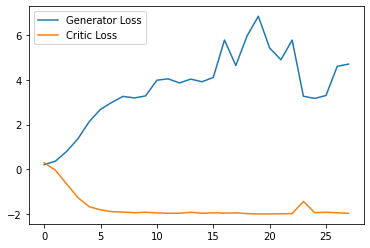

Epoch 1, step 600: Generator loss: 5.8262868309021, critic loss: -1.9895597791671753


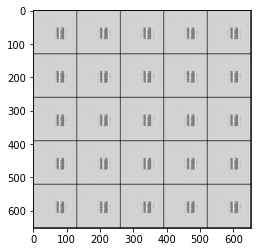

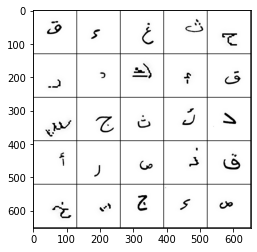

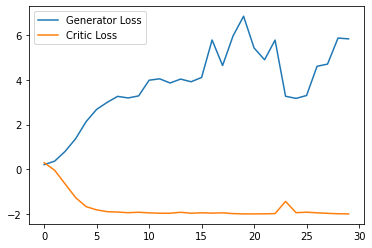

Epoch 1, step 625: Generator loss: 6.1160390663146975, critic loss: -1.9871792364120484


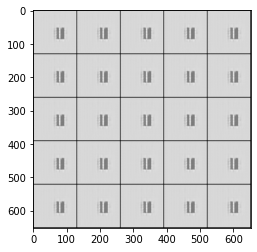

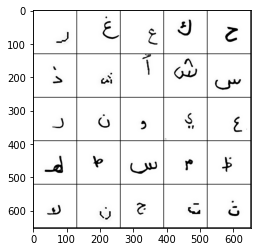

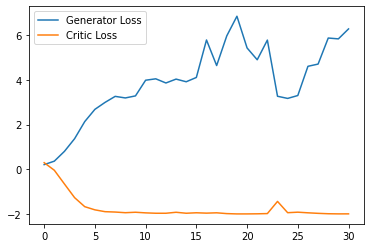

Epoch 1, step 650: Generator loss: 6.016446170806884, critic loss: -1.987668375968933


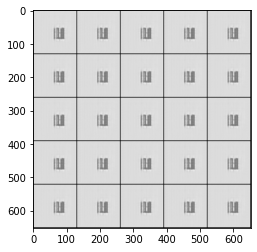

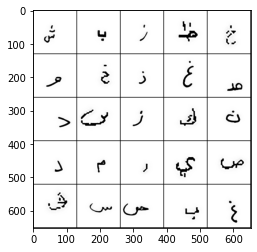

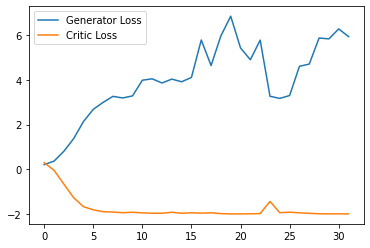

Epoch 1, step 675: Generator loss: 5.942537021636963, critic loss: -1.9819674062728883


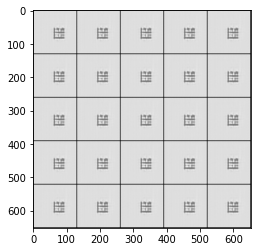

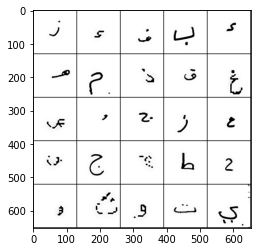

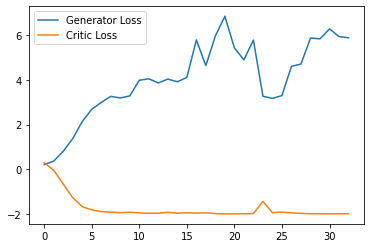

Epoch 1, step 700: Generator loss: 6.481042919158935, critic loss: -1.9553130102157592


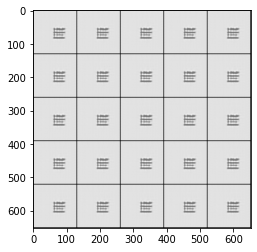

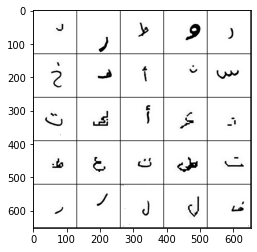

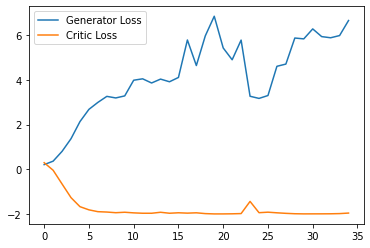

Epoch 1, step 725: Generator loss: 6.100691509246826, critic loss: -1.9860325098037719


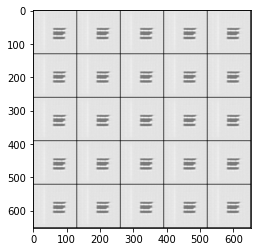

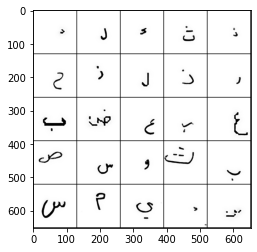

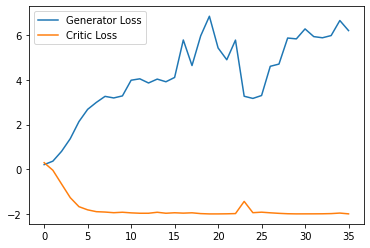

Epoch 1, step 750: Generator loss: 5.957471933364868, critic loss: -1.9791005611419679


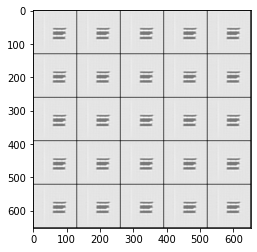

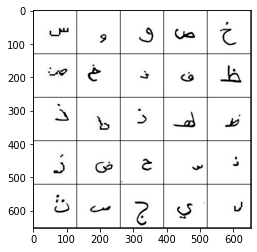

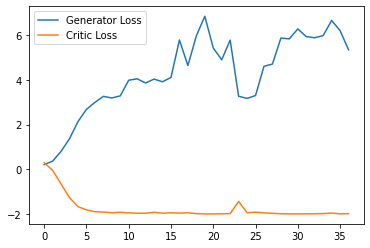

Epoch 1, step 775: Generator loss: 7.082564067840576, critic loss: -1.980229263305664


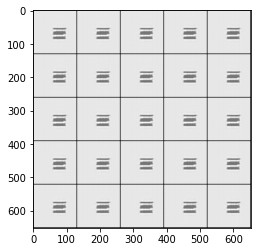

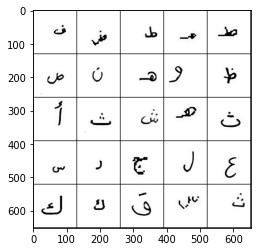

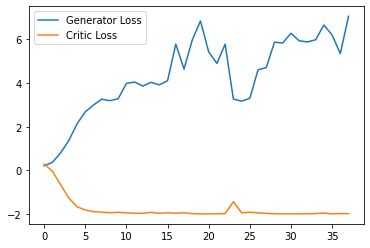

Epoch 1, step 800: Generator loss: 7.722367916107178, critic loss: -1.9917631483078002


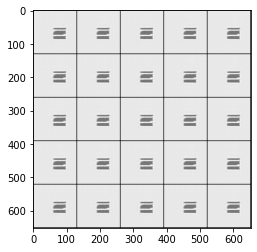

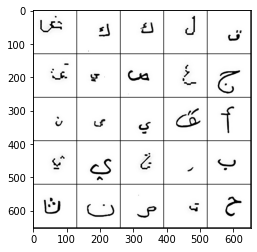

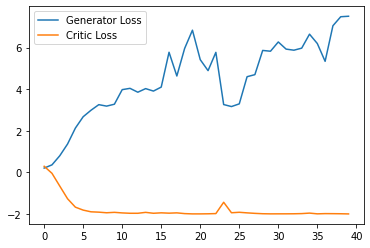

  0%|          | 0/401 [00:00<?, ?it/s]

Epoch 2, step 825: Generator loss: 7.9174798965454105, critic loss: -1.9867802143096924


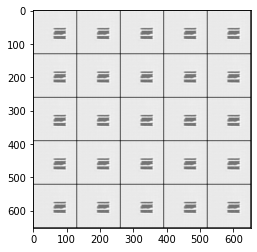

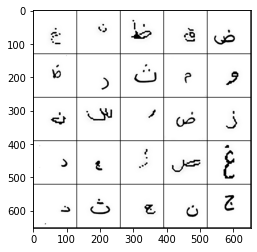

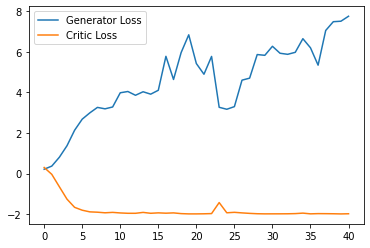

Epoch 2, step 850: Generator loss: 7.31722843170166, critic loss: -1.9976269865036012


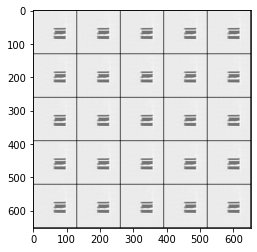

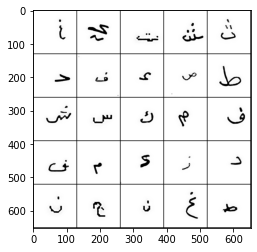

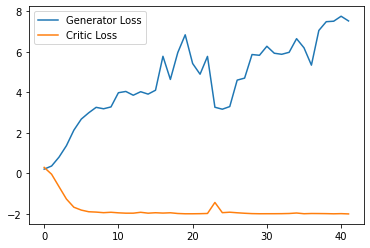

Epoch 2, step 875: Generator loss: 6.907914600372314, critic loss: -1.9966585636138916


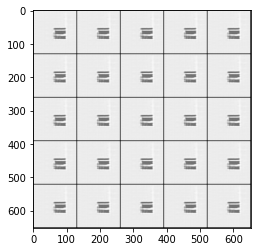

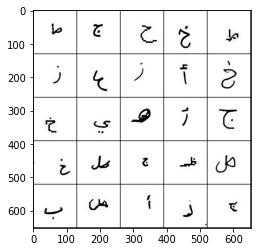

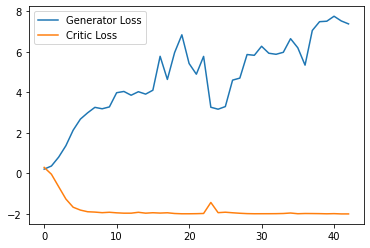

Epoch 2, step 900: Generator loss: 6.0883463096618655, critic loss: -1.9948389625549316


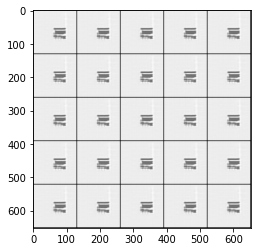

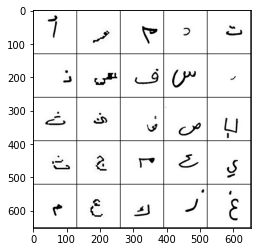

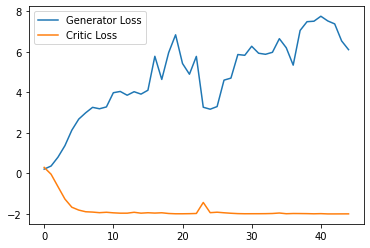

Epoch 2, step 925: Generator loss: 6.548651065826416, critic loss: -1.9959759855270385


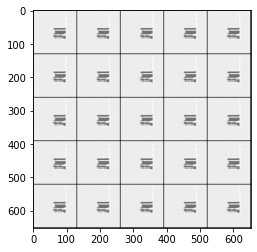

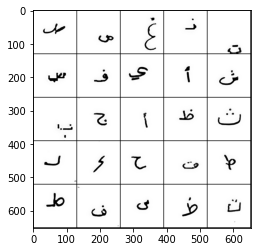

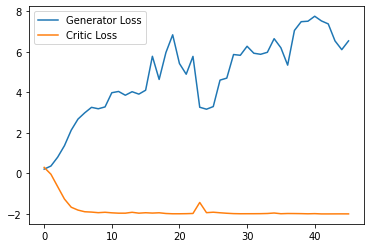

Epoch 2, step 950: Generator loss: 6.721588249206543, critic loss: -1.9949726104736327


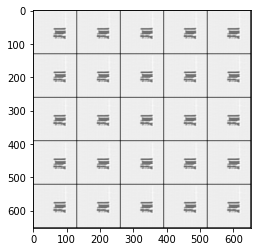

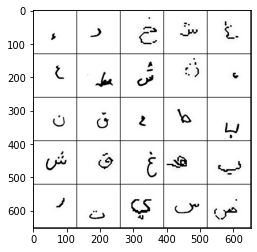

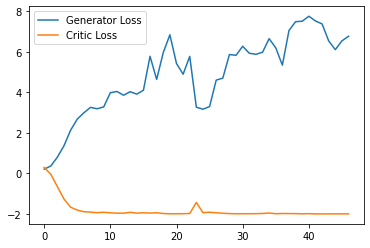

Epoch 2, step 975: Generator loss: 7.369755573272705, critic loss: -1.9965631675720215


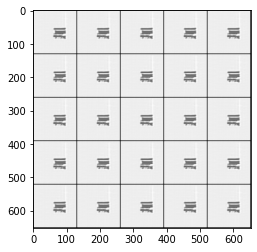

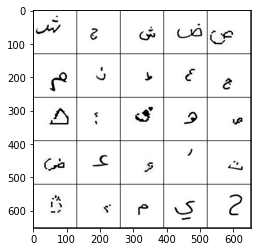

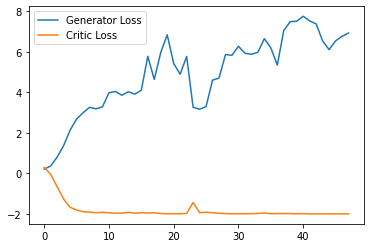

Epoch 2, step 1000: Generator loss: 7.270106410980224, critic loss: -1.9974811267852783


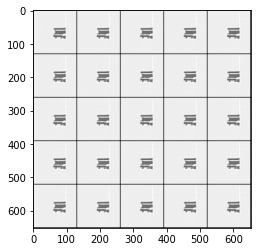

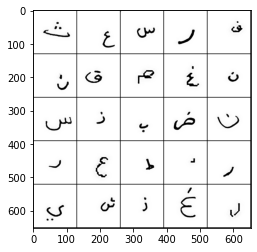

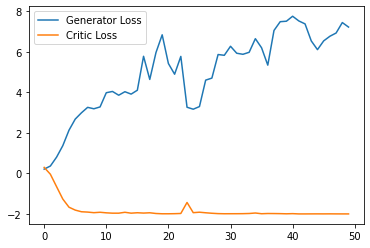

Epoch 2, step 1025: Generator loss: 7.613198280334473, critic loss: -1.9970022821426392


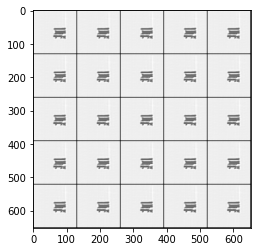

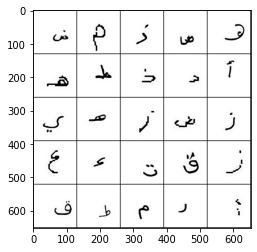

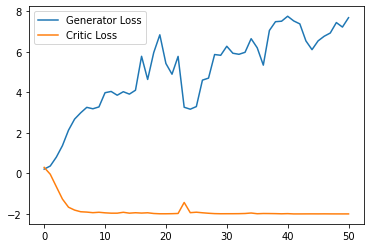

Epoch 2, step 1050: Generator loss: 7.361161365509033, critic loss: -1.9964871740341186


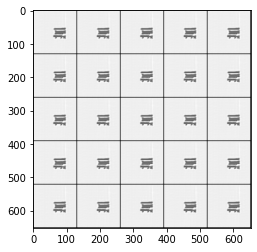

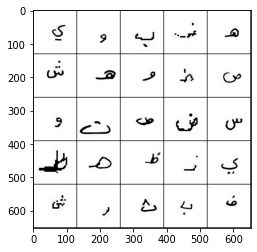

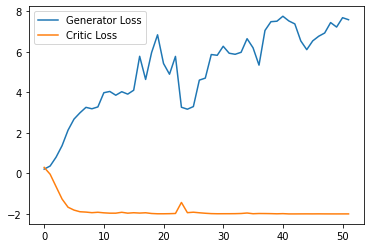

Epoch 2, step 1075: Generator loss: 7.540653266906738, critic loss: -1.9946257162094116


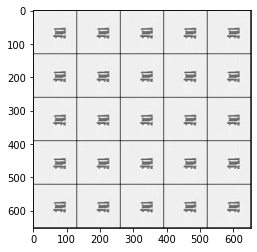

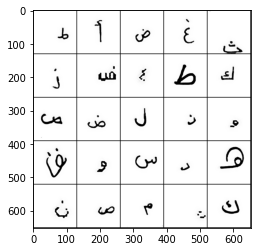

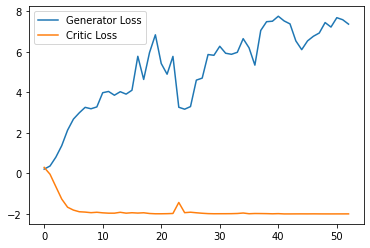

Epoch 2, step 1100: Generator loss: 5.93451917886734, critic loss: -1.5520072960853577


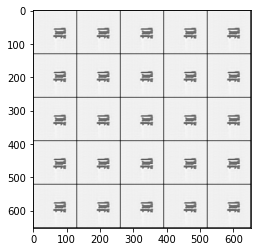

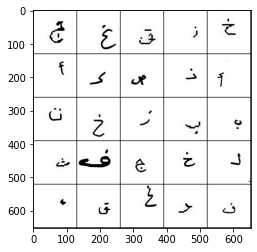

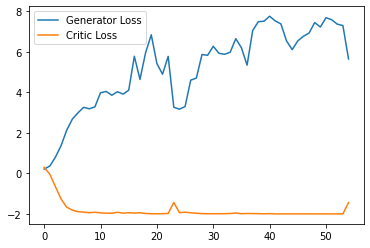

Epoch 2, step 1125: Generator loss: 3.403011178970337, critic loss: -1.875439109802246


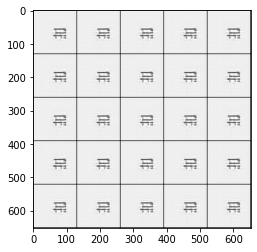

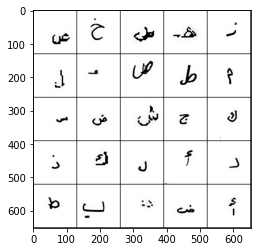

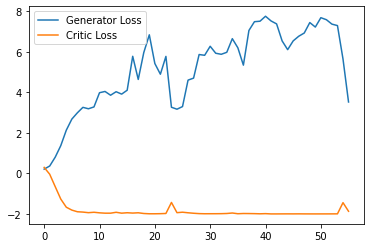

Epoch 2, step 1150: Generator loss: 4.734467554092407, critic loss: -1.9341580295562744


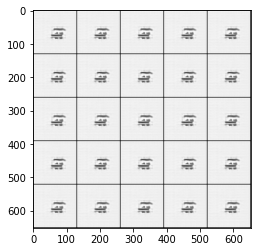

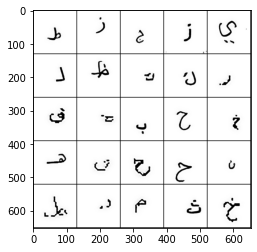

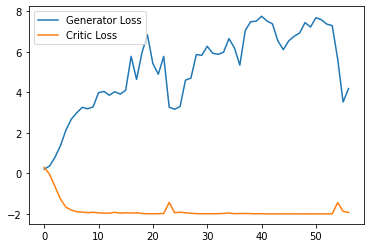

Epoch 2, step 1175: Generator loss: 5.104940357208252, critic loss: -1.954841547012329


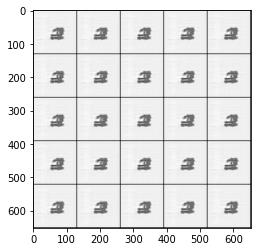

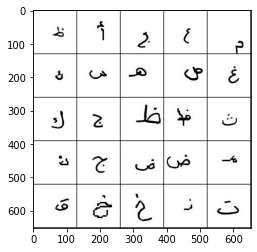

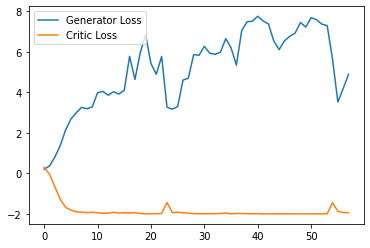

Epoch 2, step 1200: Generator loss: 4.465934114456177, critic loss: -1.9763514232635497


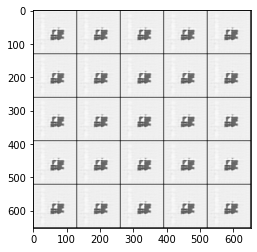

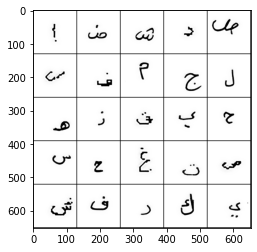

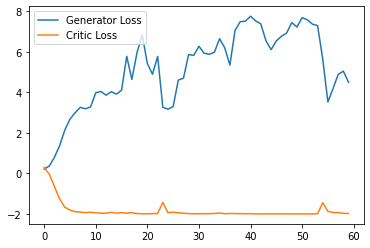

  0%|          | 0/401 [00:00<?, ?it/s]

Epoch 3, step 1225: Generator loss: 5.361582689285278, critic loss: -1.9279678344726563


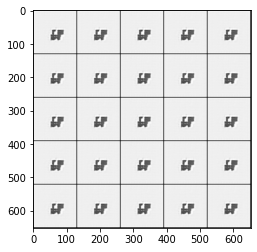

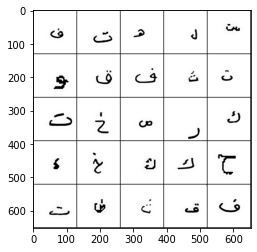

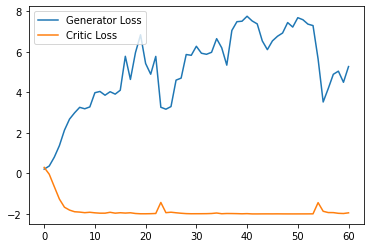

Epoch 3, step 1250: Generator loss: 6.413605260848999, critic loss: -1.9309722375869751


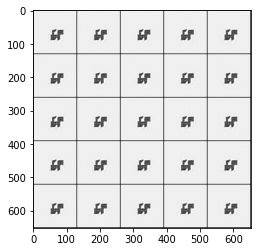

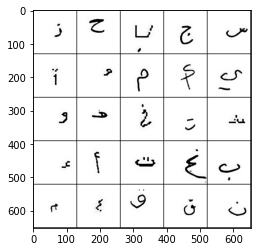

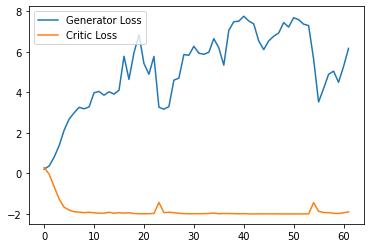

Epoch 3, step 1275: Generator loss: 5.778179321289063, critic loss: -1.956368589401245


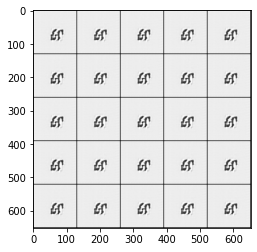

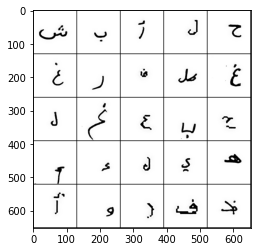

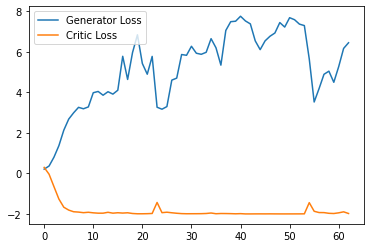

Epoch 3, step 1300: Generator loss: 5.0420422983169555, critic loss: -1.8808296346664428


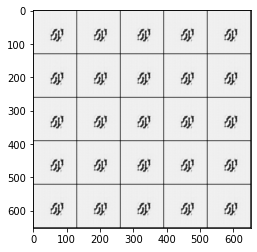

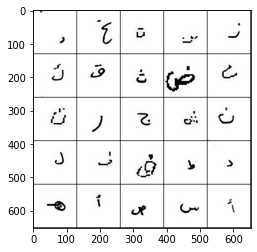

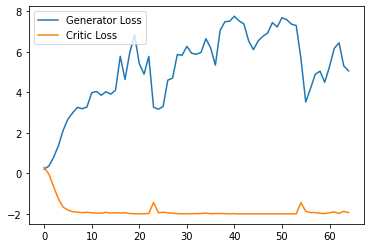

Epoch 3, step 1325: Generator loss: 5.191263961791992, critic loss: -1.8925001573562623


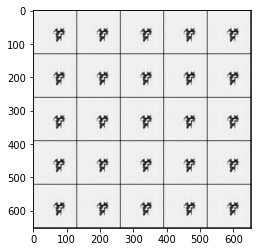

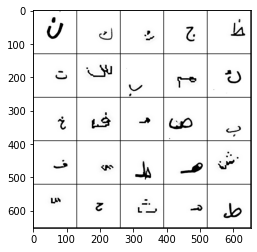

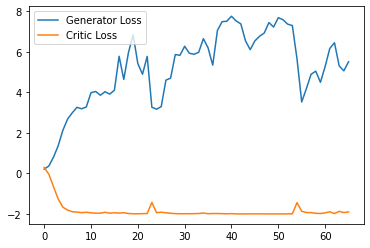

Epoch 3, step 1350: Generator loss: 4.419457273483276, critic loss: -1.901495475769043


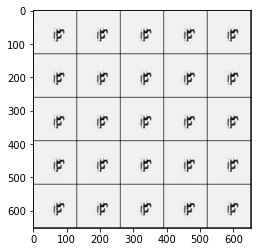

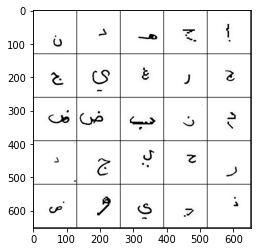

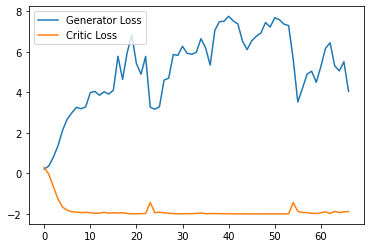

Epoch 3, step 1375: Generator loss: 4.24287106513977, critic loss: -1.8932014799118042


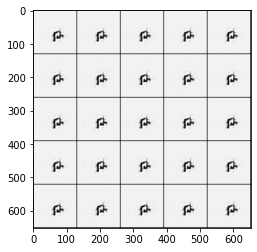

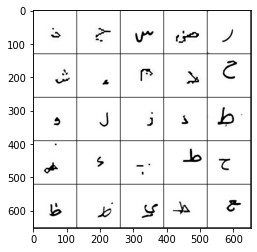

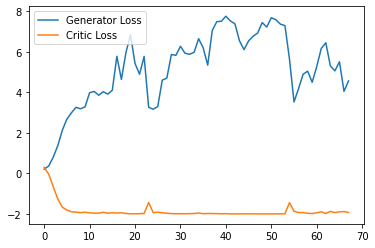

Epoch 3, step 1400: Generator loss: 4.009617710113526, critic loss: -1.690495753288269


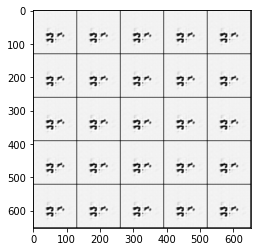

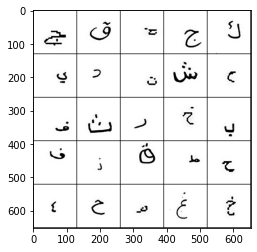

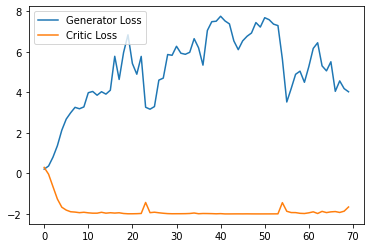

Epoch 3, step 1425: Generator loss: 3.835312314033508, critic loss: -1.6532830643653869


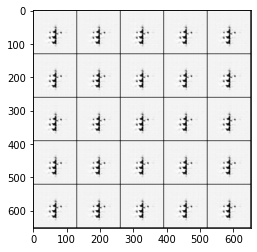

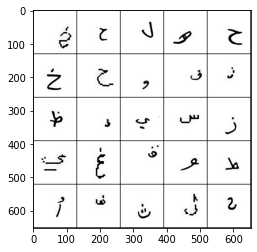

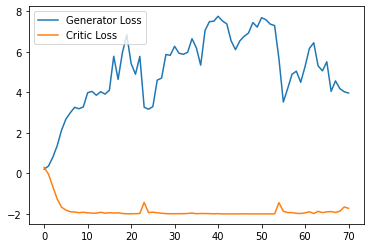

Epoch 3, step 1450: Generator loss: 4.153513121604919, critic loss: -1.7101092529296875


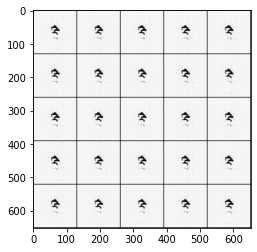

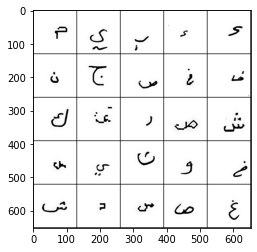

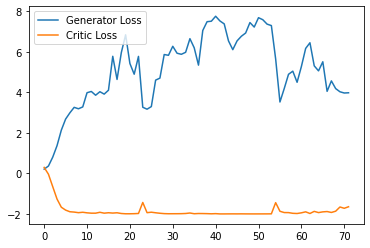

Epoch 3, step 1475: Generator loss: 3.3830122327804566, critic loss: -1.7782688331604004


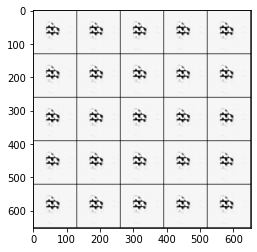

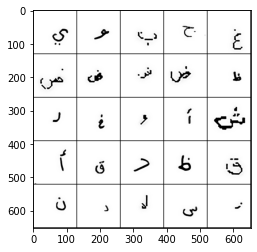

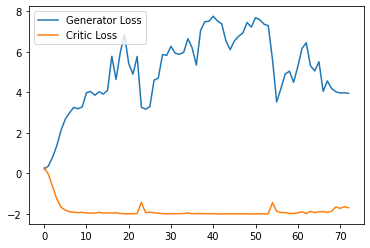

Epoch 3, step 1500: Generator loss: 3.6111971282958986, critic loss: -1.5510480976104737


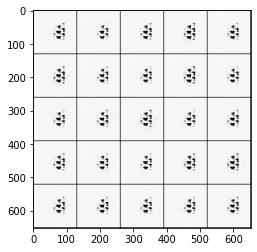

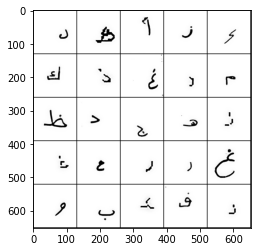

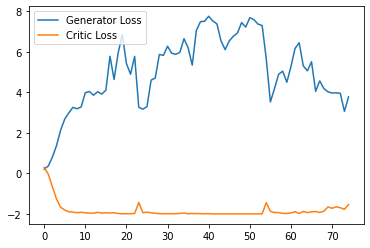

Epoch 3, step 1525: Generator loss: 4.692383451461792, critic loss: -1.6811476039886475


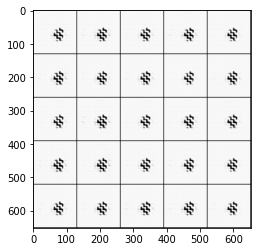

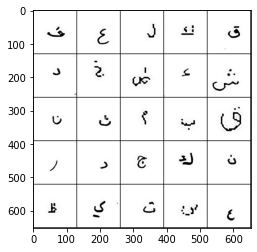

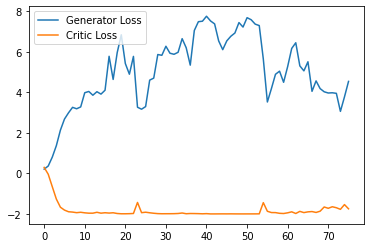

Epoch 3, step 1550: Generator loss: 4.887341413497925, critic loss: -1.8636636209487916


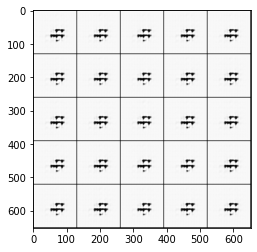

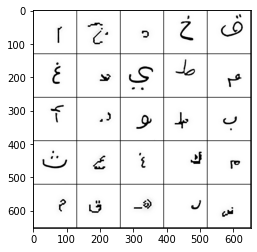

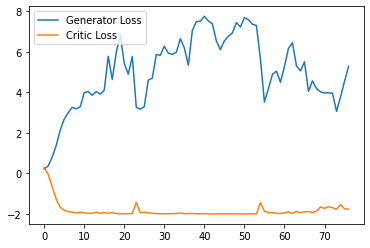

Epoch 3, step 1575: Generator loss: 4.7817944812774655, critic loss: -1.8017985582351685


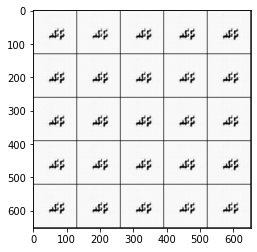

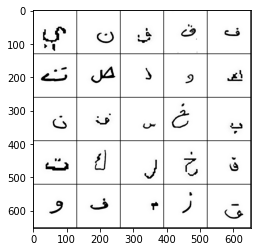

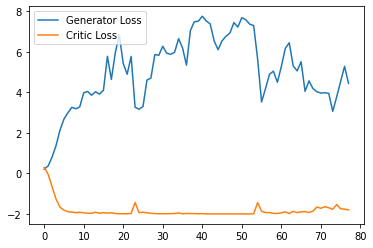

Epoch 3, step 1600: Generator loss: 3.8822740125656128, critic loss: -1.5267026925086975


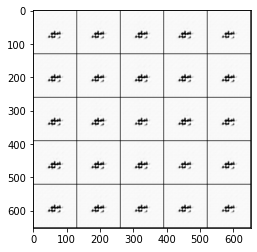

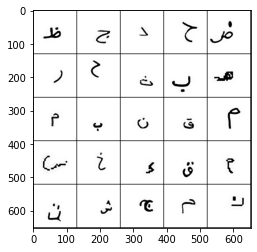

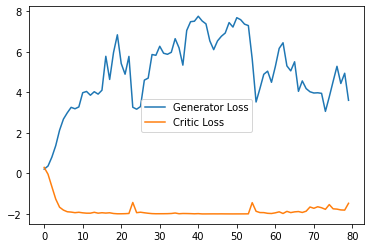

  0%|          | 0/401 [00:00<?, ?it/s]

Epoch 4, step 1625: Generator loss: 2.4861703157424926, critic loss: -1.77681574344635


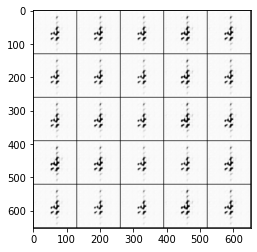

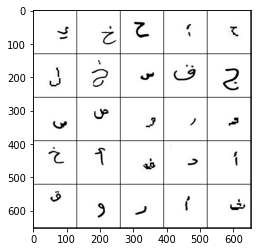

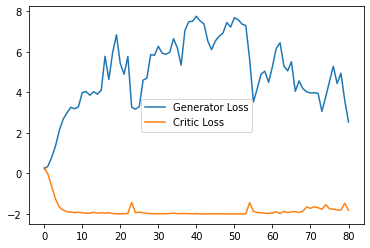

Epoch 4, step 1650: Generator loss: 2.403249201774597, critic loss: -1.5267734146118164


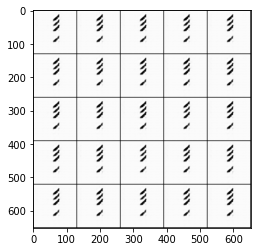

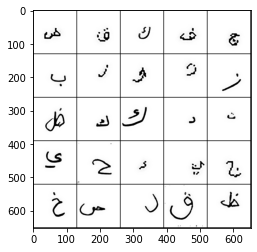

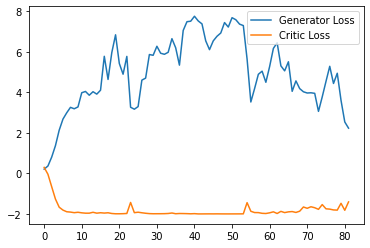

Epoch 4, step 1675: Generator loss: 3.1772709703445434, critic loss: -1.8355661535263061


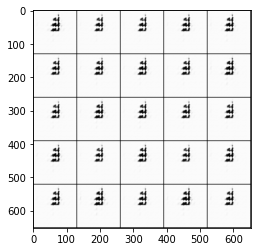

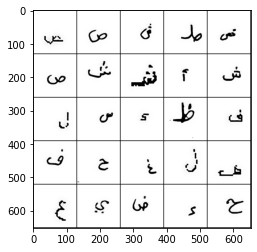

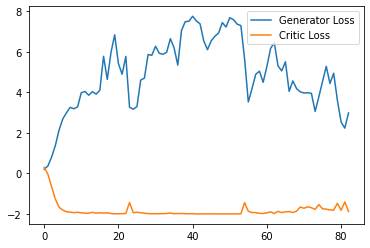

Epoch 4, step 1700: Generator loss: 2.8500266551971434, critic loss: -1.7534681749343872


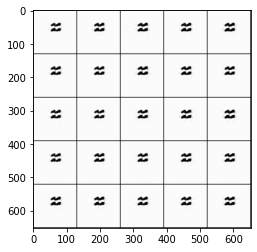

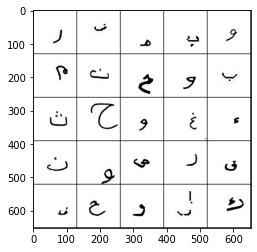

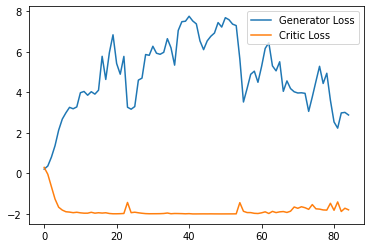

Epoch 4, step 1725: Generator loss: 3.199268856048584, critic loss: -1.8721359586715698


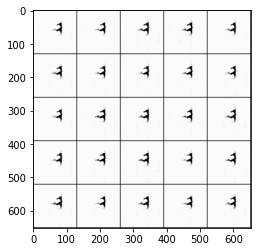

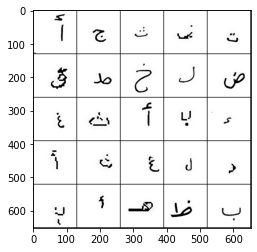

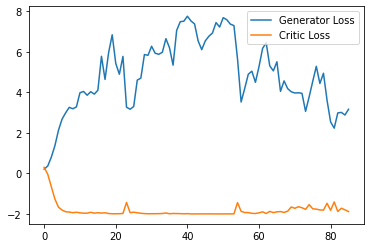

Epoch 4, step 1750: Generator loss: 3.556207036972046, critic loss: -1.8470772361755372


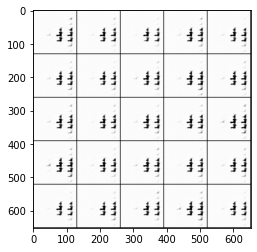

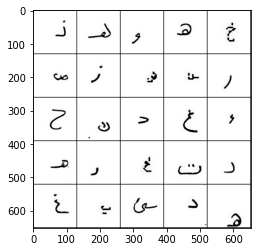

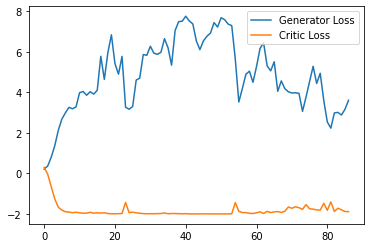

Epoch 4, step 1775: Generator loss: 4.692440786361694, critic loss: -1.8964199066162108


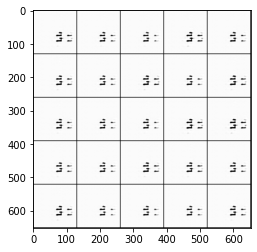

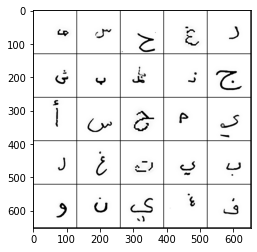

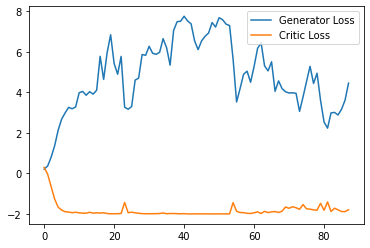

Epoch 4, step 1800: Generator loss: 4.044158926010132, critic loss: -1.9093589353561402


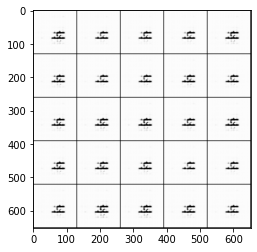

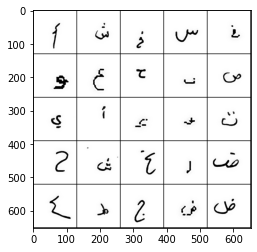

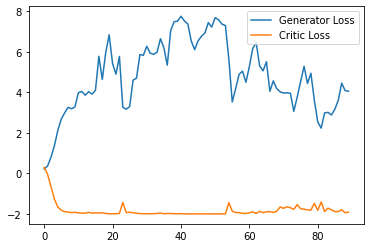

Epoch 4, step 1825: Generator loss: 4.550821361541748, critic loss: -1.758913631439209


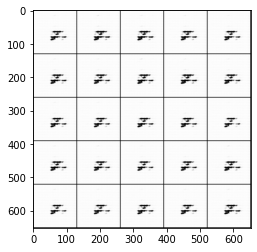

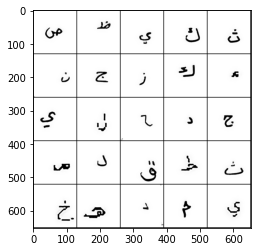

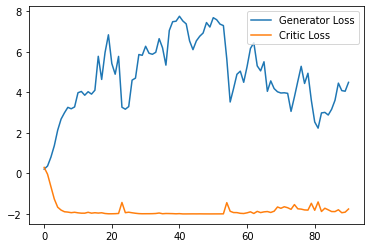

Epoch 4, step 1850: Generator loss: 4.345384664535523, critic loss: -1.8468603420257568


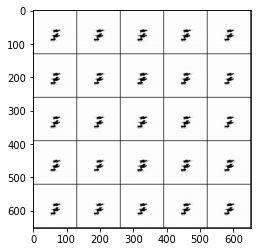

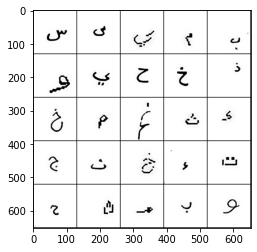

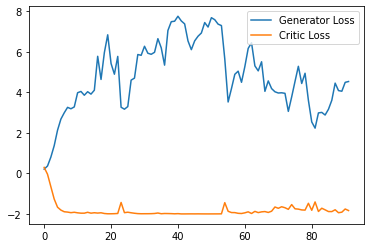

Epoch 4, step 1875: Generator loss: 3.7160480880737303, critic loss: -1.8966509628295898


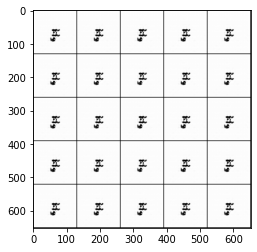

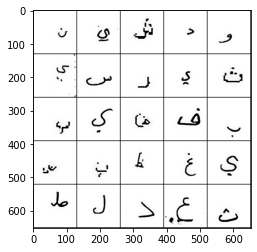

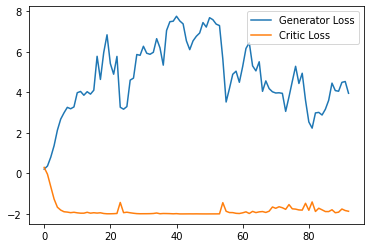

Epoch 4, step 1900: Generator loss: 3.8052667713165285, critic loss: -1.8445651197433472


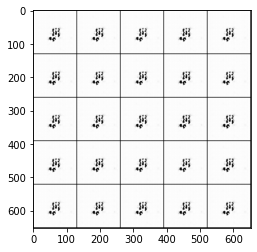

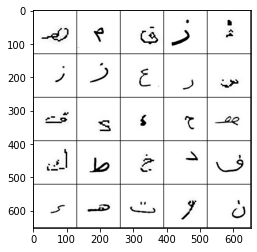

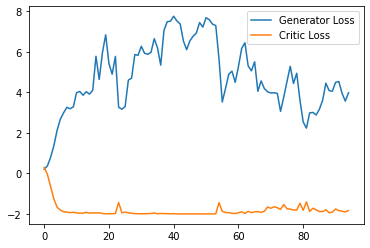

Epoch 4, step 1925: Generator loss: 3.8715533924102785, critic loss: -1.66999844789505


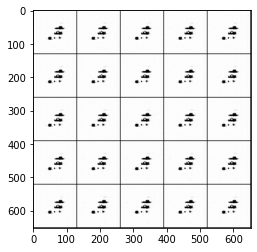

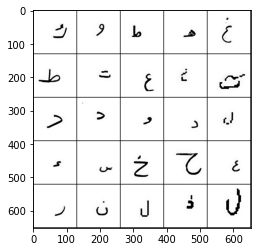

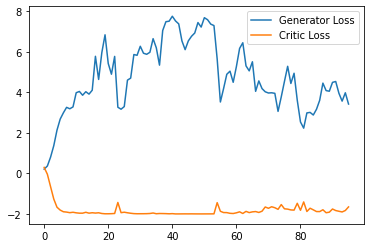

Epoch 4, step 1950: Generator loss: 4.457445135116577, critic loss: -1.9142780160903932


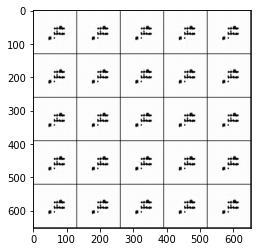

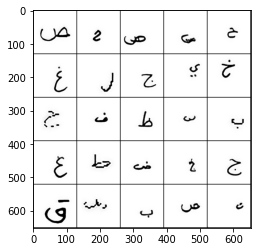

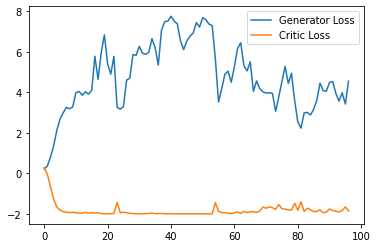

Epoch 4, step 1975: Generator loss: 4.501230721473694, critic loss: -1.8077776098251344


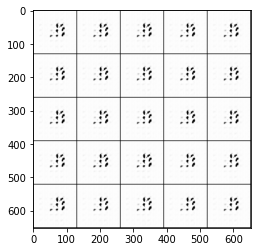

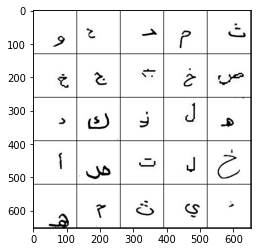

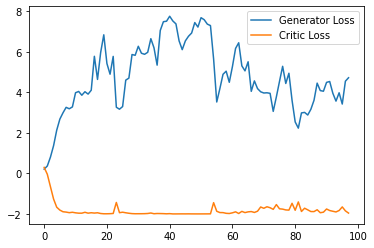

In [ ]:
Gen, Crit, Gen_Opt, Crit_Opt = GAN(trained, epochs, '', '', '', '', nDz, nGz, display_step, img_channels, crit_repeats, learning_rate, beta_1, beta_2, lambda_, z_dim, size, numClasses, dataloader, loss, device)

<p>The labels argument of generate_images function specifies which class's images to generate. Pass [0] to generate NORMAL Images and [1] to generate PNEUMONIA Images.</p>

In [ ]:
generate_images(trained, path_gen, Generator, nGz, 25, z_dim, conditional, numClasses, 25, size, [0], device) #64x64 Images

In [ ]:
# Save the generator's state dictionary
torch.save(Generator.state_dict(), './Generator_64.pth')

# Save the critic's state dictionary
torch.save(Critic.state_dict(), './Critic_64.pth')

# Save the generator optimizer's state dictionary
torch.save(Generator_Optimizer.state_dict(), './Generator_Optimizer_64.pth')

# Save the critic optimizer's state dictionary
torch.save(Critic_Optimizer.state_dict(), './Critic_Optimizer_64.pth')

In [ ]:
path_gen = './Generator_64.pth'
path_disc = './Critic_64.pth'
path_gen_opt = './Generator_Optimizer_64.pth'
path_disc_opt = './Critic_Optimizer_64.pth'

<p>This is a sample generation of 64x64 pneumonic images for testing purposes when the model was trained for ~150 epochs. But it won't work now because we are using 256x256 images</p>

In [ ]:
generate_images(True, path_gen, [], 64, 25, 100, True, 2, 25, (1, 64, 64), [1], 'cuda')